In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv('dataset_phishing.csv', encoding='latin1')
data

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,0,448,5396,3980,0,0,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,1,0,0,85,2836,2455493,0,0,4,legitimate


In [3]:
data.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [4]:
data.shape

(11430, 89)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [6]:
data.isna().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

In [7]:
data.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,0.998317,...,0.330460,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000


In [8]:
print(f"Duplicate rows: {data.duplicated().sum()}")

Duplicate rows: 0


In [9]:
df_clean = data.drop(columns=['url'])

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['status'] = le.fit_transform(df_clean['status'])
print("--- Target Distribution ---")
print(df_clean['status'].value_counts())
print("\n")

--- Target Distribution ---
status
0    5715
1    5715
Name: count, dtype: int64




In [11]:
df_clean.head()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,37,19,0,3,0,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,77,23,1,1,0,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,126,50,1,4,1,0,1,2,0,3,...,1,0,0,14,4004,5828815,0,1,0,1
3,18,11,0,2,0,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,0
4,55,15,0,2,2,0,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,0


In [12]:
(df_clean.corr()["status"].sort_values(ascending=False)*100).head(11)


status              100.000000
google_index         73.117084
ratio_digits_url     35.639457
domain_in_title      34.280697
phish_hints          33.539274
ip                   32.169778
nb_qm                29.431907
length_url           24.858047
nb_slash             24.226996
length_hostname      23.832240
nb_eq                23.338630
Name: status, dtype: float64

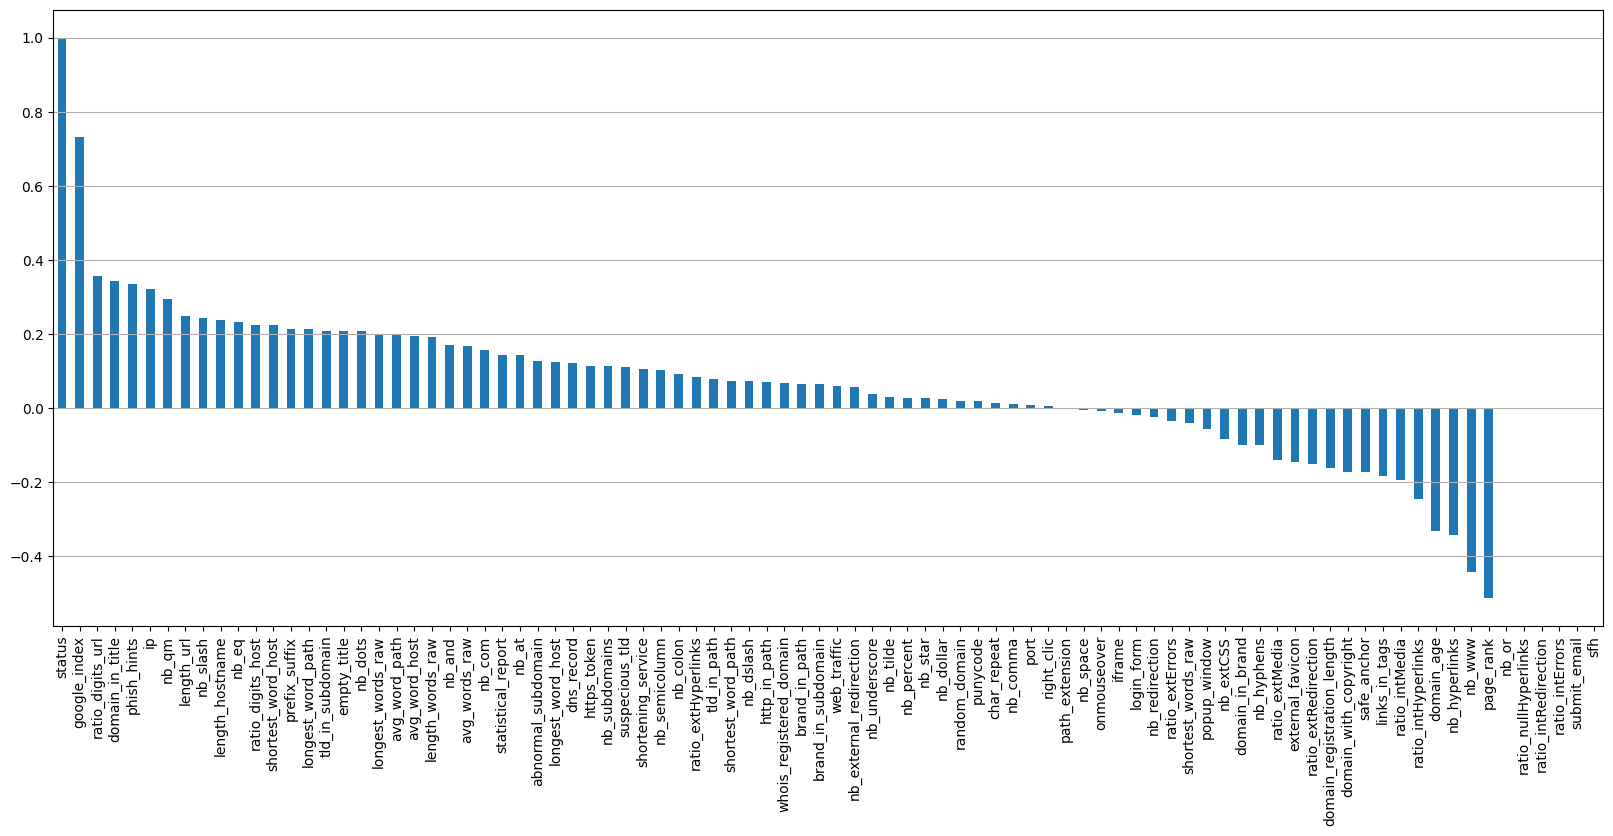

In [13]:
plt.figure(figsize=(20,8))

df_clean.corr()["status"].sort_values(ascending=False).plot(kind='bar')
plt.grid(axis='y', linestyle='-')
plt.show()

C:\Users\Liwa08\AppData\Local\Temp\ipykernel_29860\3705406005.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y='ratio_digits_url',x='status',  ax=ax[1], palette='coolwarm')


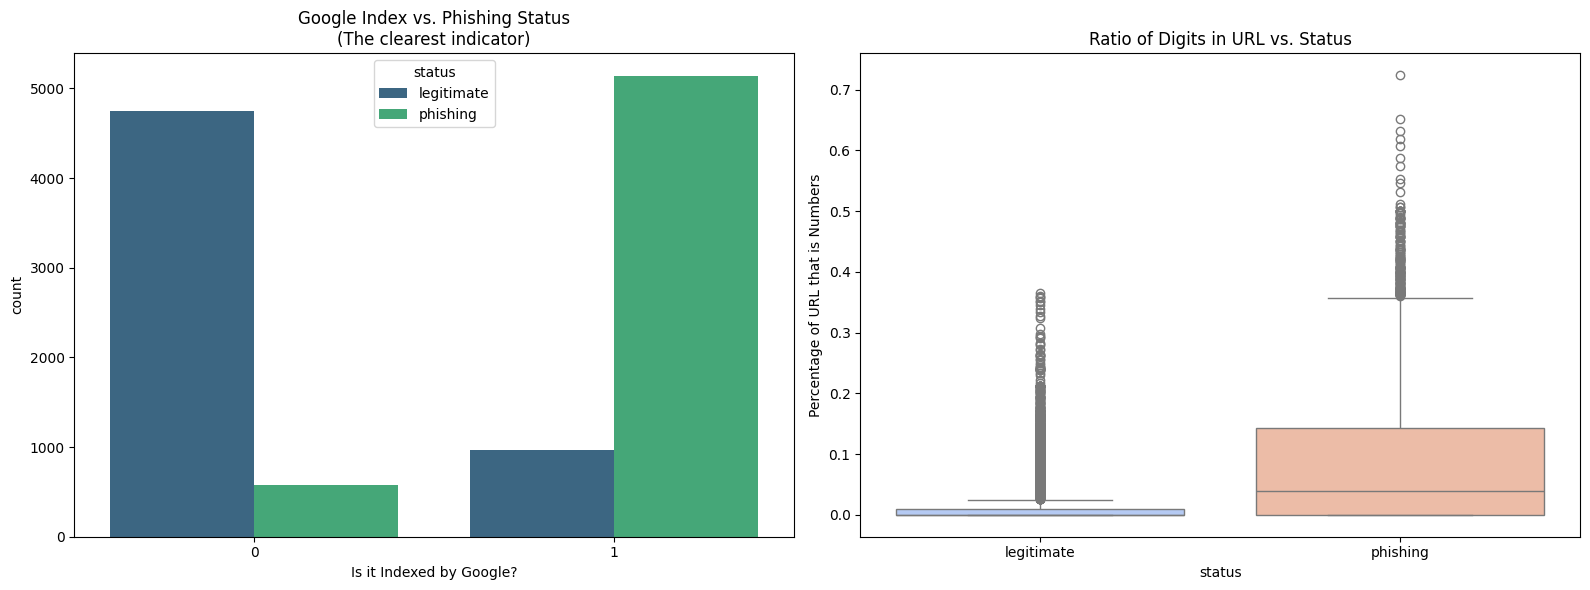

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Google Index 
# We use a countplot to see how many phishing vs legit sites are indexed
sns.countplot(data=data, x='google_index', hue='status', ax=ax[0], palette='viridis')
ax[0].set_title('Google Index vs. Phishing Status\n(The clearest indicator)')
ax[0].set_xlabel('Is it Indexed by Google?')

# Plot 2: Ratio of Digits in URL
# We use a Box Plot to see the spread of numbers in the URL
sns.boxplot(data=data, y='ratio_digits_url',x='status',  ax=ax[1], palette='coolwarm')
ax[1].set_title('Ratio of Digits in URL vs. Status')
ax[1].set_ylabel('Percentage of URL that is Numbers')

plt.tight_layout()
plt.show()

## Decision Tree Model

Training the Decision Tree Model... 
Accuracy using Decision Trees Model: 93.22%
Calculating Learning Curve... 


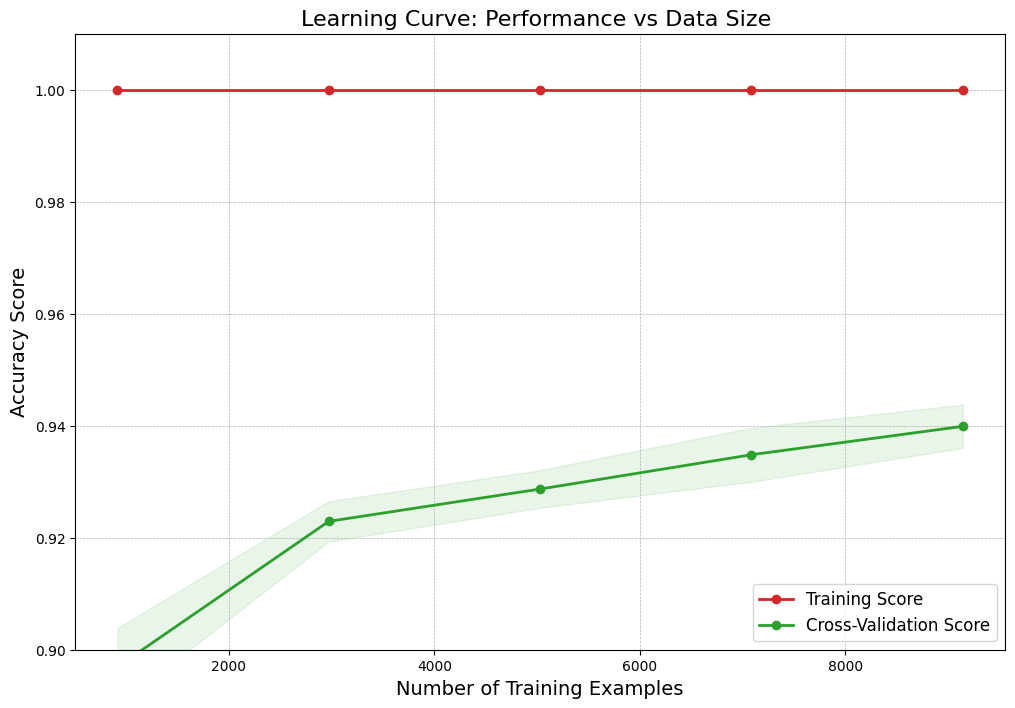

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Create new X with only these columns
X_selected = df_clean.drop(columns='status')
y = df_clean['status']

# 3. Split (80/20)
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print("Training the Decision Tree Model... ")
# 4. Train the Model
model_selected = DecisionTreeClassifier(criterion = 'entropy')
model_selected.fit(X_train_sel, y_train_sel)

# 5. Check the Score
acc = accuracy_score(y_test_sel, model_selected.predict(X_test_sel))
print(f"Accuracy using Decision Trees Model: {acc:.2%}")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

print("Calculating Learning Curve... ")

# Calculate the curve data
train_sizes, train_scores, test_scores = learning_curve(
    model_selected, X_selected, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting just the Learning Curve
plt.figure(figsize=(12, 8))

# Training Line (Red)
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score", linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")

# Validation Line (Green)
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Cross-Validation Score", linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")

# ZOOM IN (Focus on 90% - 101%)
plt.ylim(0.90, 1.01)

plt.title("Learning Curve: Performance vs Data Size ", fontsize=16)
plt.xlabel("Number of Training Examples", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=14)
plt.legend(loc="best", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [16]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluating Model...")
y_pred_sel = model_selected.predict(X_test_sel)

accuracy_sel = accuracy_score(y_test_sel, y_pred_sel)
precision_sel = precision_score(y_test_sel, y_pred_sel)
recall_sel = recall_score(y_test_sel, y_pred_sel)
f1_sel = f1_score(y_test_sel, y_pred_sel)
conf_matrix_sel = confusion_matrix(y_test_sel, y_pred_sel)
print(f"Accuracy: {accuracy_sel:.4f}")
print(f"Precision: {precision_sel:.4f}")
print(f"Recall: {recall_sel:.4f}")
print(f"F1-Score: {f1_sel:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_sel)

print("\n--- Confusion Matrix Breakdown ---")
TN, FP, FN, TP = conf_matrix_sel.ravel()
print(f"True Negatives (Legitimate Correctly Classified): {TN}")
print(f"False Positives (Legitimate Classified as Phishing): {FP}")
print(f"False Negatives (Phishing Classified as Legitimate): {FN}")
print(f"True Positives (Phishing Correctly Classified): {TP}")

Evaluating Model...
Accuracy: 0.9322
Precision: 0.9279
Recall: 0.9353
F1-Score: 0.9316

Confusion Matrix:
[[1075   82]
 [  73 1056]]

--- Confusion Matrix Breakdown ---
True Negatives (Legitimate Correctly Classified): 1075
False Positives (Legitimate Classified as Phishing): 82
False Negatives (Phishing Classified as Legitimate): 73
True Positives (Phishing Correctly Classified): 1056


C:\Users\Liwa08\AppData\Local\Temp\ipykernel_29860\2076214317.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=RF_metrics_df, ax=axes[1], palette='viridis')


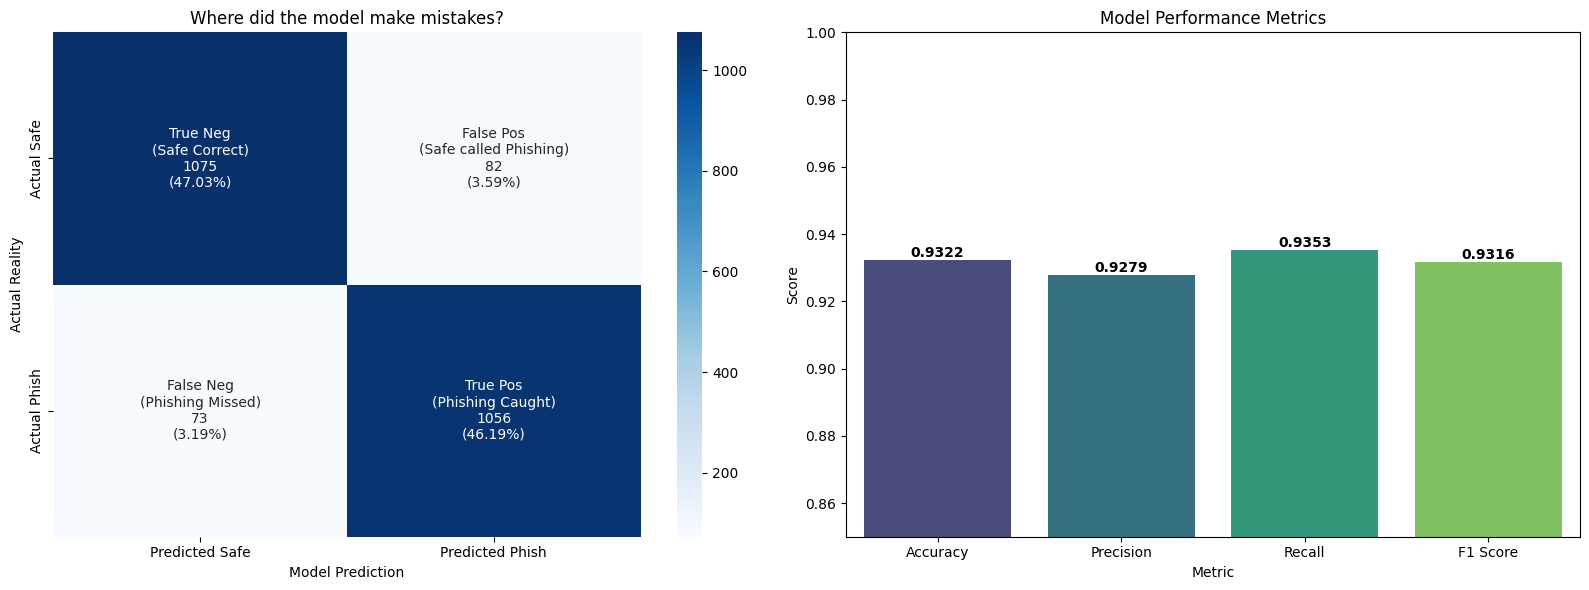

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define the custom annotations for the heatmap
# This maps the technical terms (TN, FP) to readable text
group_names = ['True Neg\n(Safe Correct)', 'False Pos\n(Safe called Phishing)', 
               'False Neg\n(Phishing Missed)', 'True Pos\n(Phishing Caught)']

# Format the counts and percentages
group_counts = ["{0:0.0f}".format(value) for value in conf_matrix_sel.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in conf_matrix_sel.flatten()/np.sum(conf_matrix_sel)]

# Combine them into one label per box
labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- CHART 1: The Detailed Confusion Matrix ---
sns.heatmap(conf_matrix_sel, annot=labels, fmt='', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Safe', 'Predicted Phish'],
            yticklabels=['Actual Safe', 'Actual Phish'])
axes[0].set_title('Where did the model make mistakes?')
axes[0].set_xlabel('Model Prediction')
axes[0].set_ylabel('Actual Reality')

# --- CHART 2: The Performance Report Card ---
RF_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy_sel, precision_sel, recall_sel, f1_sel]
})

sns.barplot(x='Metric', y='Score', data=RF_metrics_df, ax=axes[1], palette='viridis')
axes[1].set_title('Model Performance Metrics')
axes[1].set_ylim(0.85, 1.0) # Zoom in the Y-axis since scores are high

# Add the actual numbers on top of the bars
for index, row in RF_metrics_df.iterrows():
    axes[1].text(index, row.Score, f"{row.Score:.4f}", color='black', ha="center", va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Liwa08\AppData\Local\Temp\ipykernel_29860\4121426051.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')


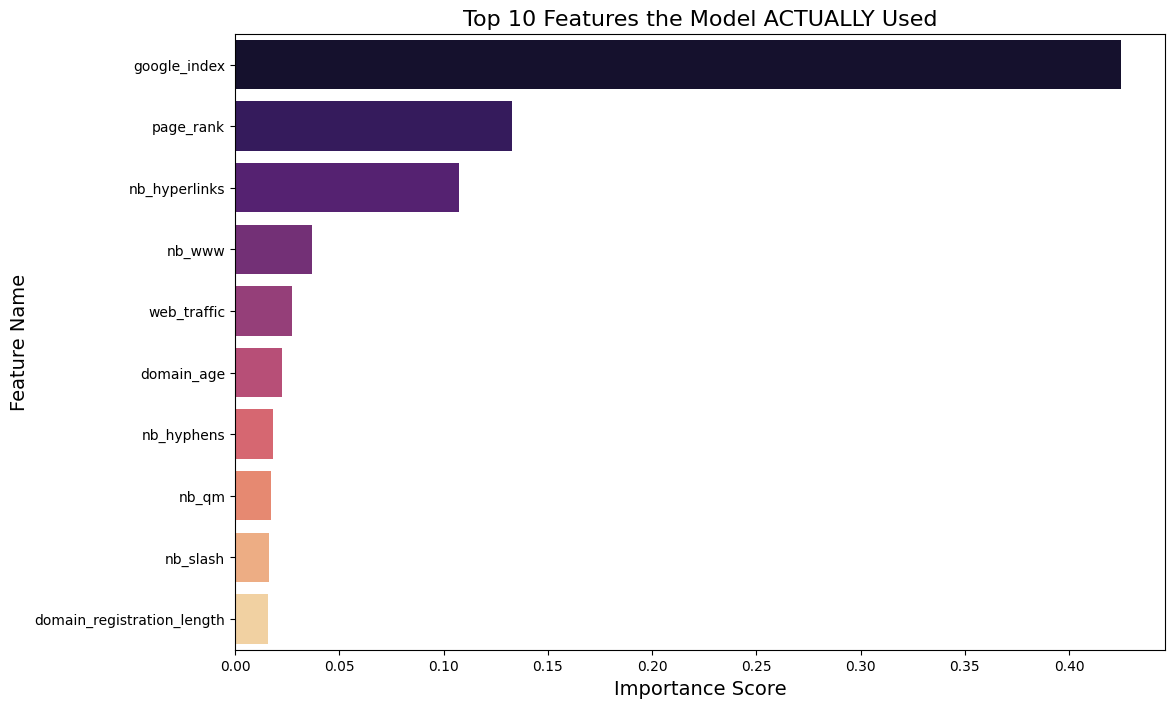

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the feature importances from the model
importances = pd.DataFrame({
    'Feature': X_selected.columns,
    'Importance': model_selected.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

# Plotting just the Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')

plt.title('Top 10 Features the Model ACTUALLY Used', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature Name', fontsize=14)
plt.show()

## Random Forest Model

Training the Random Forest Model... 
--- Final Test Accuracy: 96.94% ---
Calculating Learning Curve... 


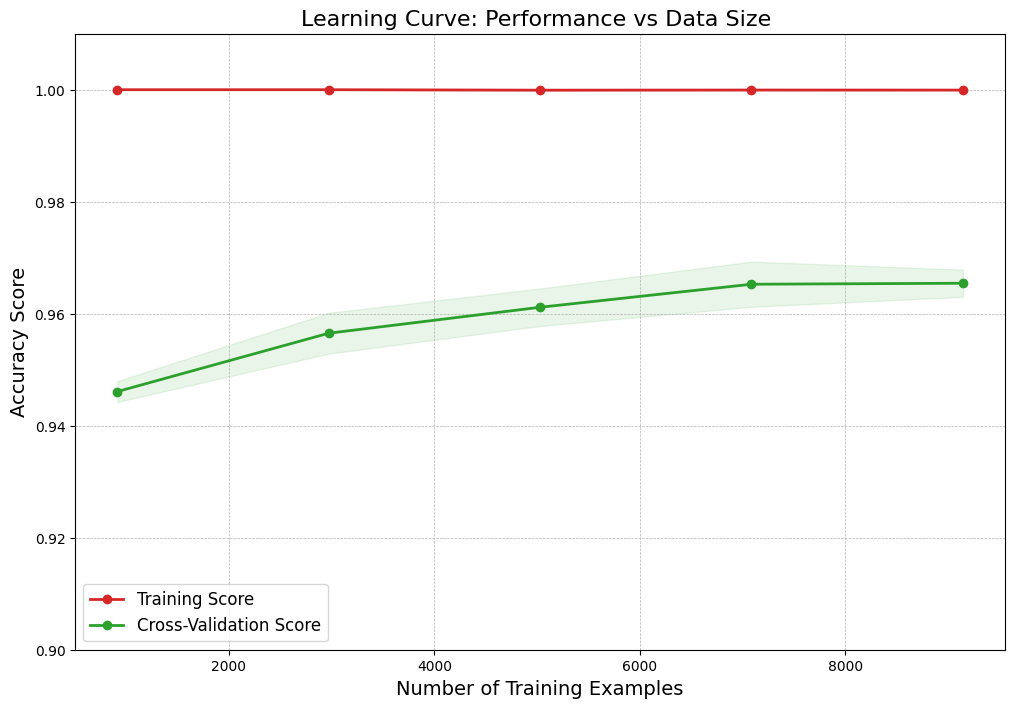

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

X = df_clean.drop(columns=['status'])
y = df_clean['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the Random Forest Model... ")

RF_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
RF_model.fit(X_train, y_train)

# Check Final Accuracy
full_acc = accuracy_score(y_test, RF_model.predict(X_test))
print(f"--- Final Test Accuracy: {full_acc:.2%} ---")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

print("Calculating Learning Curve... ")

# Calculate the curve data
train_sizes, train_scores, test_scores = learning_curve(
    RF_model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting just the Learning Curve
plt.figure(figsize=(12, 8))

# Training Line (Red)
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score", linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")

# Validation Line (Green)
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Cross-Validation Score", linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")

# ZOOM IN (Focus on 90% - 101%)
plt.ylim(0.90, 1.01)

plt.title("Learning Curve: Performance vs Data Size ", fontsize=16)
plt.xlabel("Number of Training Examples", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=14)
plt.legend(loc="best", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()


In [20]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluating Model...")
y_pred = RF_model.predict(X_test)

RF_accuracy = accuracy_score(y_test, y_pred)
RF_precision = precision_score(y_test, y_pred)
RF_recall = recall_score(y_test, y_pred)
RF_f1 = f1_score(y_test, y_pred)
RF_conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {RF_accuracy:.4f}")
print(f"Precision: {RF_precision:.4f}")
print(f"Recall: {RF_recall:.4f}")
print(f"F1-Score: {RF_f1:.4f}")

print("\nConfusion Matrix:")
print(RF_conf_matrix)

print("\n--- Confusion Matrix Breakdown ---")
TN, FP, FN, TP = RF_conf_matrix.ravel()
print(f"True Negatives (Legitimate Correctly Classified): {TN}")
print(f"False Positives (Legitimate Classified as Phishing): {FP}")
print(f"False Negatives (Phishing Classified as Legitimate): {FN}")
print(f"True Positives (Phishing Correctly Classified): {TP}")

Evaluating Model...
Accuracy: 0.9694
Precision: 0.9749
Recall: 0.9628
F1-Score: 0.9688

Confusion Matrix:
[[1129   28]
 [  42 1087]]

--- Confusion Matrix Breakdown ---
True Negatives (Legitimate Correctly Classified): 1129
False Positives (Legitimate Classified as Phishing): 28
False Negatives (Phishing Classified as Legitimate): 42
True Positives (Phishing Correctly Classified): 1087


C:\Users\Liwa08\AppData\Local\Temp\ipykernel_29860\3843285621.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=RF_metrics_df, ax=axes[1], palette='viridis')


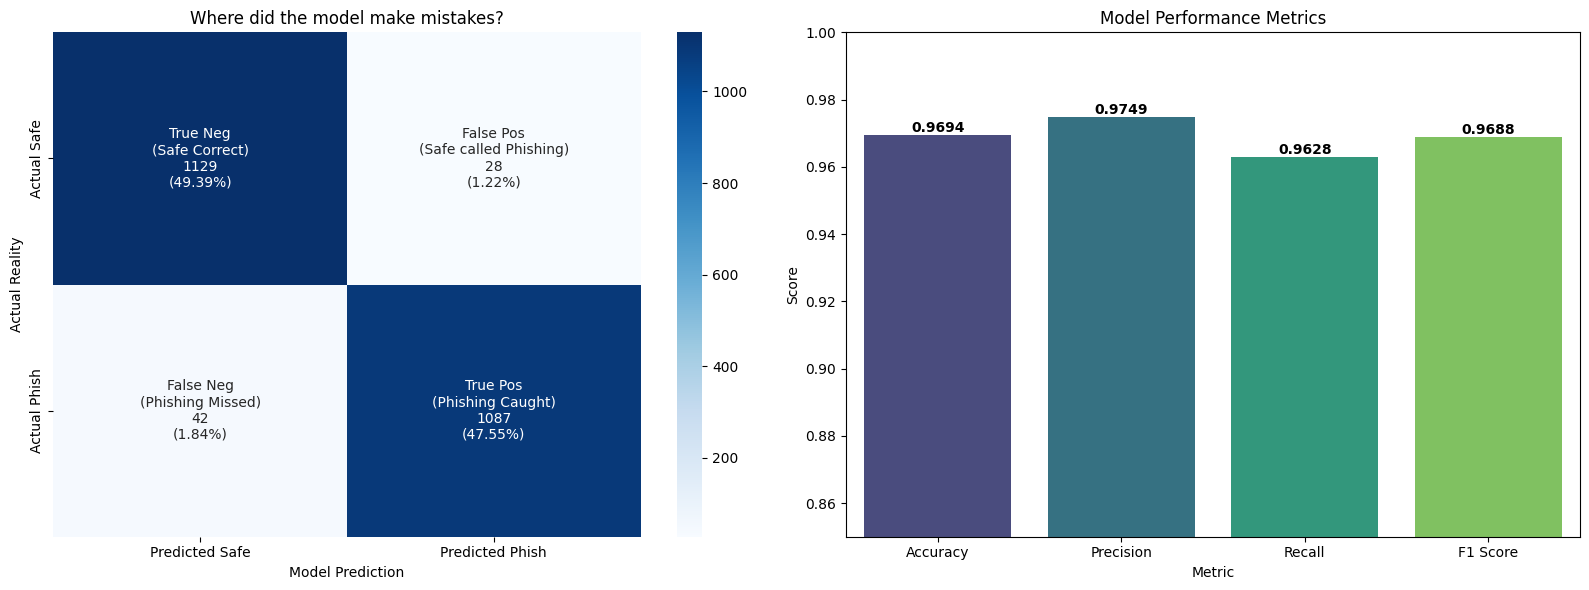

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define the custom annotations for the heatmap
# This maps the technical terms (TN, FP) to readable text
group_names = ['True Neg\n(Safe Correct)', 'False Pos\n(Safe called Phishing)', 
               'False Neg\n(Phishing Missed)', 'True Pos\n(Phishing Caught)']

# Format the counts and percentages
group_counts = ["{0:0.0f}".format(value) for value in RF_conf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in RF_conf_matrix.flatten()/np.sum(RF_conf_matrix)]

# Combine them into one label per box
labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- CHART 1: The Detailed Confusion Matrix ---
sns.heatmap(RF_conf_matrix, annot=labels, fmt='', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Safe', 'Predicted Phish'],
            yticklabels=['Actual Safe', 'Actual Phish'])
axes[0].set_title('Where did the model make mistakes?')
axes[0].set_xlabel('Model Prediction')
axes[0].set_ylabel('Actual Reality')

# --- CHART 2: The Performance Report Card ---
RF_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [RF_accuracy, RF_precision, RF_recall, RF_f1]
})

sns.barplot(x='Metric', y='Score', data=RF_metrics_df, ax=axes[1], palette='viridis')
axes[1].set_title('Model Performance Metrics')
axes[1].set_ylim(0.85, 1.0) # Zoom in the Y-axis since scores are high

# Add the actual numbers on top of the bars
for index, row in RF_metrics_df.iterrows():
    axes[1].text(index, row.Score, f"{row.Score:.4f}", color='black', ha="center", va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Liwa08\AppData\Local\Temp\ipykernel_29860\669280849.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')


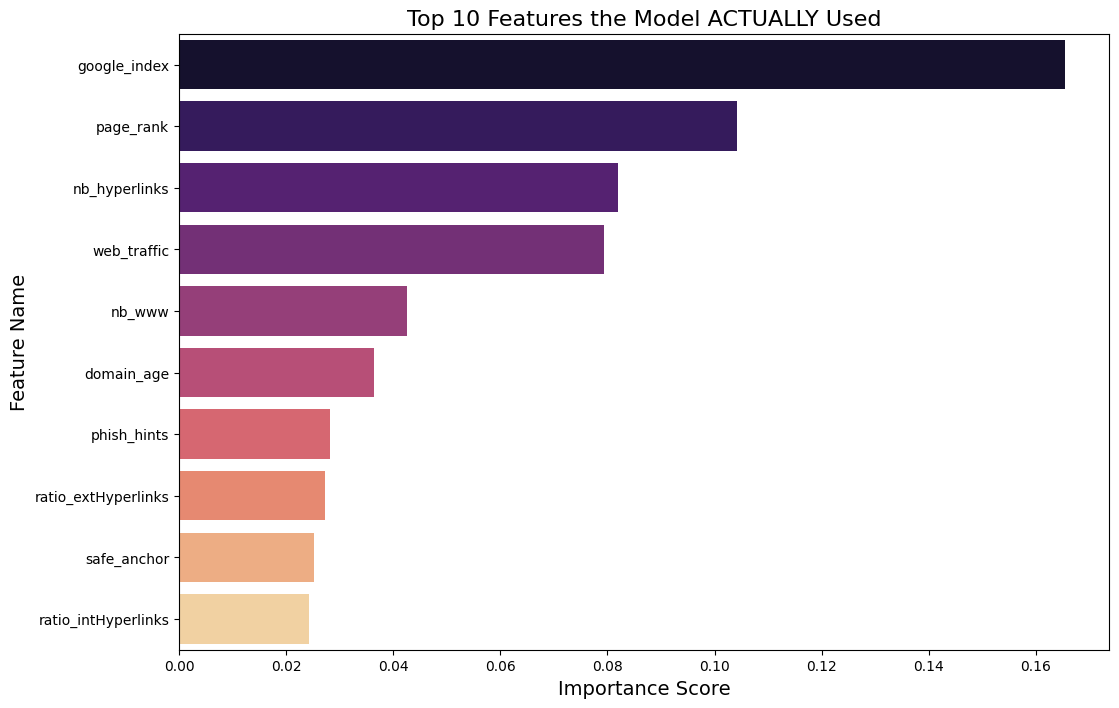

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the feature importances from the model
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': RF_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

# Plotting just the Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')

plt.title('Top 10 Features the Model ACTUALLY Used', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature Name', fontsize=14)
plt.show()

## XGBoost Model

Training the XGBoost Model... 
--- Final Test Accuracy: 97.33% ---
Calculating Learning Curve... 


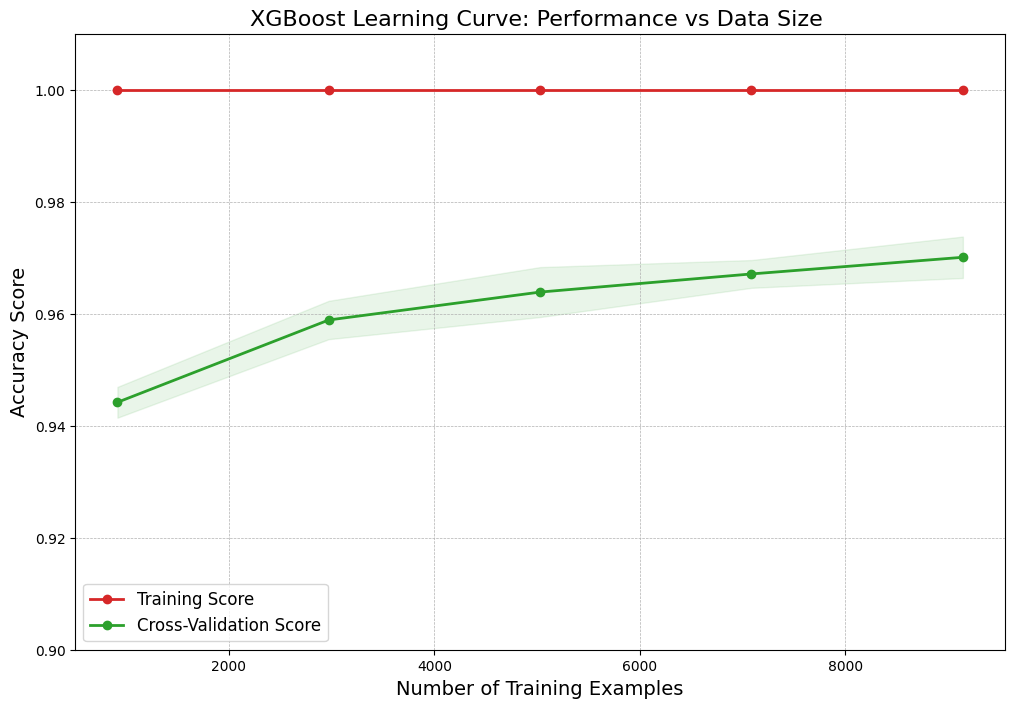

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier  # <--- CHANGED IMPORT
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score
# Optional: Import LabelEncoder if your target 'y' is text (e.g., 'phishing', 'safe')
from sklearn.preprocessing import LabelEncoder 

# Assuming df_clean is already loaded
X = df_clean.drop(columns=['status'])
y = df_clean['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the XGBoost Model... ")

# <--- CHANGED MODEL INITIALIZATION
xgb_model = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    eval_metric='logloss' # Good practice to silence warnings for binary classification
)

xgb_model.fit(X_train, y_train)

# Check Final Accuracy
full_acc = accuracy_score(y_test, xgb_model.predict(X_test))
print(f"--- Final Test Accuracy: {full_acc:.2%} ---")

print("Calculating Learning Curve... ")

# Calculate the curve data
# <--- UPDATED MODEL REFERENCE HERE
train_sizes, train_scores, test_scores = learning_curve(
    xgb_model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting just the Learning Curve
plt.figure(figsize=(12, 8))

# Training Line (Red)
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score", linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")

# Validation Line (Green)
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Cross-Validation Score", linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")

# ZOOM IN (Focus on 90% - 101%)
# Note: If XGBoost accuracy is lower than 90%, you may need to adjust this limit.
plt.ylim(0.90, 1.01) 

plt.title("XGBoost Learning Curve: Performance vs Data Size ", fontsize=16)
plt.xlabel("Number of Training Examples", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=14)
plt.legend(loc="best", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluating XGBoost Model...")

# Use the XGBoost model for prediction
y_pred = xgb_model.predict(X_test)

# Calculate metrics with new variable names
xgb_acc = accuracy_score(y_test, y_pred)
xgb_precision = precision_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy: {xgb_acc:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")

print("\nConfusion Matrix:")
print(xgb_conf_matrix)

print("\n--- Confusion Matrix Breakdown ---")
# Extract TN, FP, FN, TP
TN, FP, FN, TP = xgb_conf_matrix.ravel()

print(f"True Negatives (Legitimate Correctly Classified): {TN}")
print(f"False Positives (Legitimate Classified as Phishing): {FP}")
print(f"False Negatives (Phishing Classified as Legitimate): {FN}")
print(f"True Positives (Phishing Correctly Classified): {TP}")

Evaluating XGBoost Model...
Accuracy: 0.9733
Precision: 0.9742
Recall: 0.9717
F1-Score: 0.9729

Confusion Matrix:
[[1128   29]
 [  32 1097]]

--- Confusion Matrix Breakdown ---
True Negatives (Legitimate Correctly Classified): 1128
False Positives (Legitimate Classified as Phishing): 29
False Negatives (Phishing Classified as Legitimate): 32
True Positives (Phishing Correctly Classified): 1097


C:\Users\Liwa08\AppData\Local\Temp\ipykernel_29860\3763501264.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=RF_metrics_df, ax=axes[1], palette='viridis')


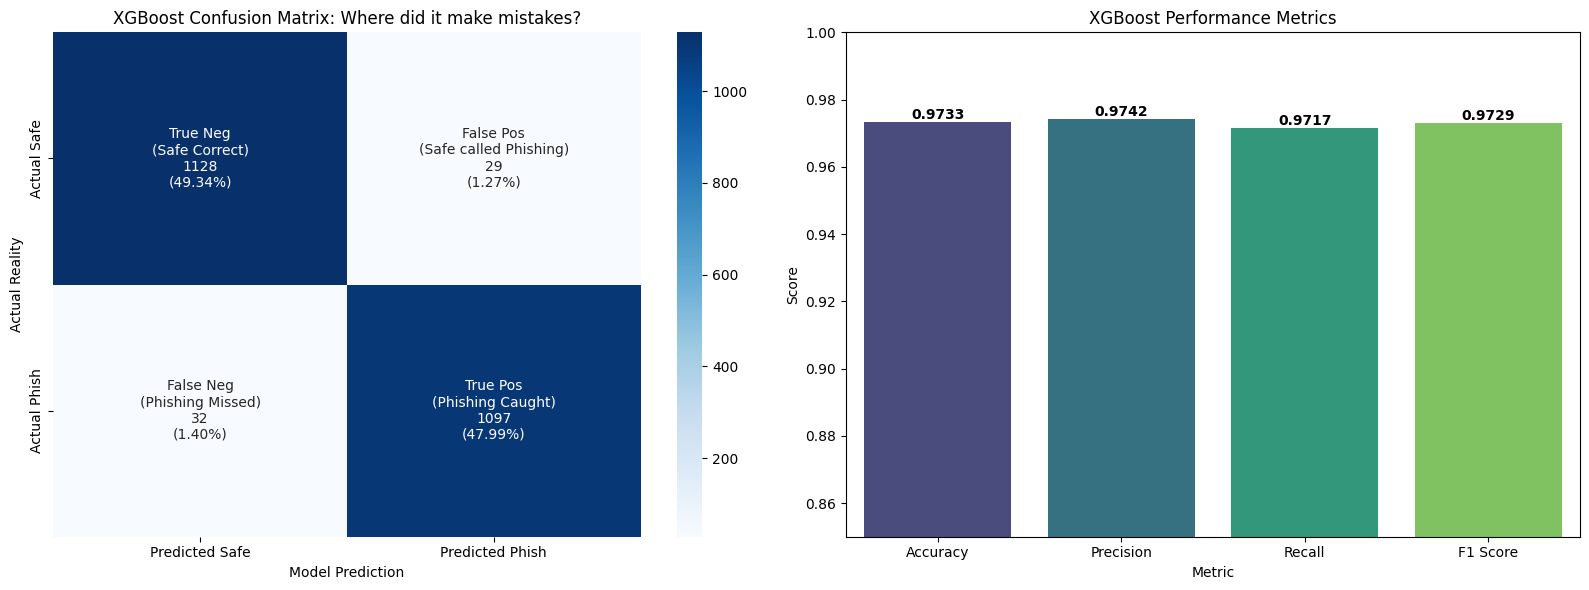

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define the custom annotations for the heatmap
group_names = ['True Neg\n(Safe Correct)', 'False Pos\n(Safe called Phishing)', 
               'False Neg\n(Phishing Missed)', 'True Pos\n(Phishing Caught)']

# Format the counts and percentages using xgb_conf_matrix
group_counts = ["{0:0.0f}".format(value) for value in xgb_conf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in xgb_conf_matrix.flatten()/np.sum(xgb_conf_matrix)]

# Combine them into one label per box
labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- CHART 1: The Detailed Confusion Matrix ---
sns.heatmap(xgb_conf_matrix, annot=labels, fmt='', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Safe', 'Predicted Phish'],
            yticklabels=['Actual Safe', 'Actual Phish'])
axes[0].set_title('XGBoost Confusion Matrix: Where did it make mistakes?')
axes[0].set_xlabel('Model Prediction')
axes[0].set_ylabel('Actual Reality')

# --- CHART 2: The Performance Report Card ---
RF_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [xgb_acc, xgb_precision, xgb_recall, xgb_f1]
})

sns.barplot(x='Metric', y='Score', data=RF_metrics_df, ax=axes[1], palette='viridis')
axes[1].set_title('XGBoost Performance Metrics')
axes[1].set_ylim(0.85, 1.0) # Zoom in the Y-axis since scores are high

# Add the actual numbers on top of the bars
for index, row in RF_metrics_df.iterrows():
    axes[1].text(index, row.Score, f"{row.Score:.4f}", color='black', ha="center", va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Liwa08\AppData\Local\Temp\ipykernel_29860\4269466765.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')


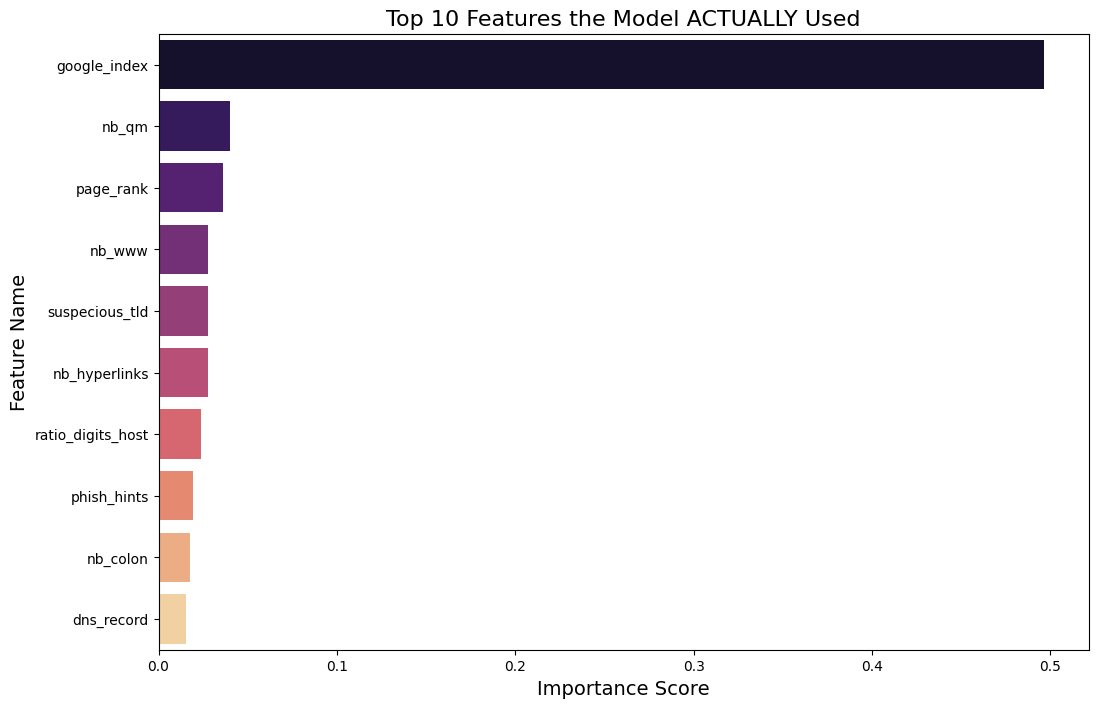

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the feature importances from the model
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

# Plotting just the Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma')

plt.title('Top 10 Features the Model ACTUALLY Used', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature Name', fontsize=14)
plt.show()

## Comparaison Between the Models

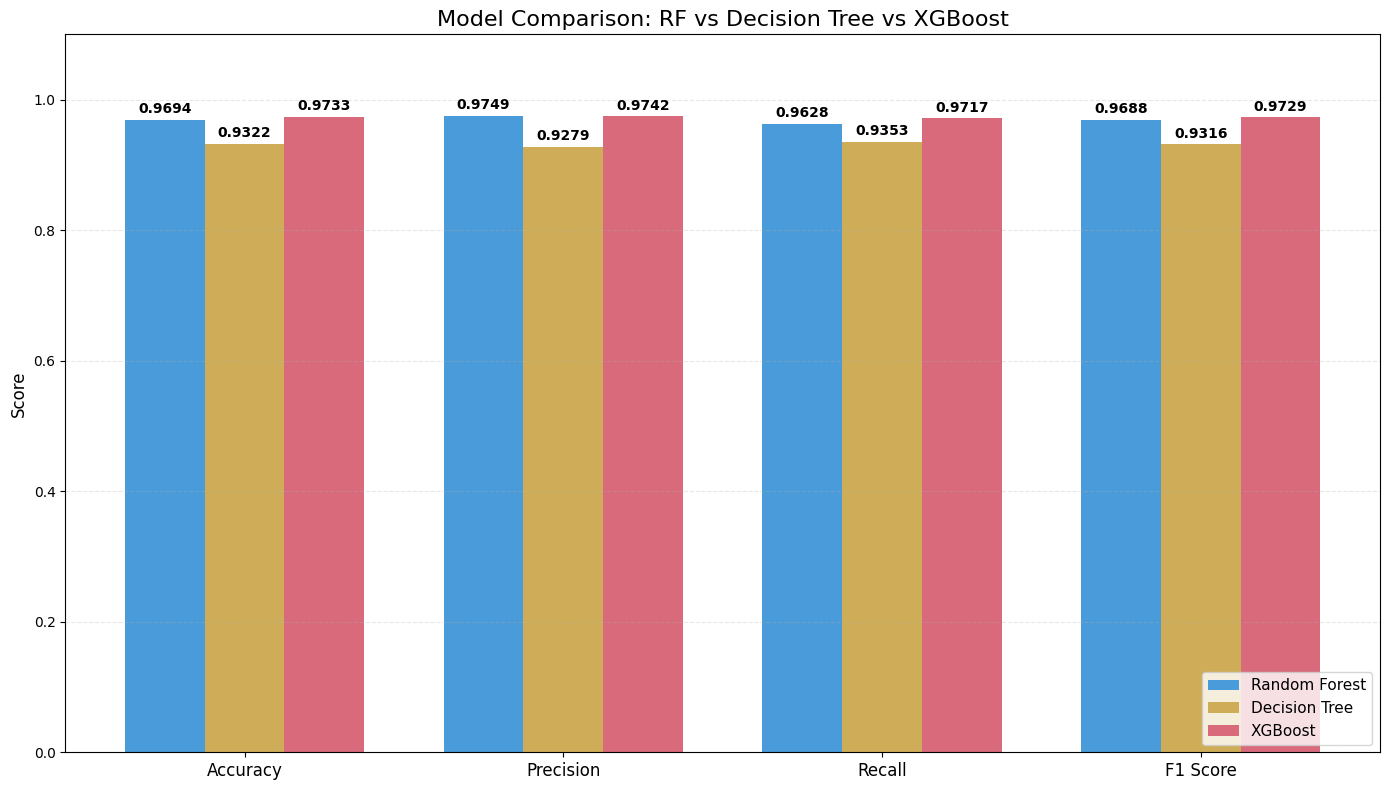

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  # Importing numpy makes handling position arrays easier

# 1. Define Scores for all 3 models
# (Assuming you have these variables from previous steps)
RF_model_scores = {
    "Accuracy": RF_accuracy,
    "Precision": RF_precision,
    "Recall": RF_recall,
    "F1 Score": RF_f1
}

DT_model_scores = {
    "Accuracy": accuracy_sel,
    "Precision": precision_sel,
    "Recall": recall_sel,
    "F1 Score": f1_sel
}

XGB_model_scores = {
    "Accuracy": xgb_acc,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1
}

# 2. Create DataFrame
metrics_df = pd.DataFrame({
    "Metric": list(RF_model_scores.keys()),
    "Random Forest": list(RF_model_scores.values()),
    "Decision Tree": list(DT_model_scores.values()),
    "XGBoost": list(XGB_model_scores.values())
})

# 3. Plotting
plt.figure(figsize=(14, 8))
plt.title("Model Comparison: RF vs Decision Tree vs XGBoost", fontsize=16)

# Define positions
x = np.arange(len(metrics_df))  # [0, 1, 2, 3]
width = 0.25  # Thinner bars to fit 3 of them

# Define Colors
rf_color = "#4a9bd9"    # Blue
dt_color = "#CFAD58"    # Gold
xgb_color = "#d86a7c"   

# Plot 3 sets of bars
# Shift RF to left (-0.25), DT in middle (0), XGB to right (+0.25)
plt.bar(x - width, metrics_df["Random Forest"], width=width, label="Random Forest", color=rf_color)
plt.bar(x,         metrics_df["Decision Tree"], width=width, label="Decision Tree", color=dt_color)
plt.bar(x + width, metrics_df["XGBoost"],       width=width, label="XGBoost",       color=xgb_color)

# 4. Add numeric labels above the bars
def add_labels(x_positions, column_name):
    for i, v in enumerate(metrics_df[column_name]):
        plt.text(x_positions[i], v + 0.01, f"{v:.4f}", ha='center', fontsize=10, fontweight='bold')

add_labels(x - width, "Random Forest")
add_labels(x,         "Decision Tree")
add_labels(x + width, "XGBoost")

# 5. Final touches
plt.xticks(x, metrics_df["Metric"], fontsize=12)
plt.ylim(0, 1.1)  # Increase limit slightly to fit labels
plt.ylabel("Score", fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()